In [7]:
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import os
from PIL import Image
from sklearn.model_selection import train_test_split





/home/thierry/PycharmProjects/Outils-IA/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.7271   
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 0.7263
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 0.7256
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 0.7249
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5000 - loss: 0.7242
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5000 - loss: 0.7234
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5000 - loss: 0.7227
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5000 - loss: 0.7220
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5000 - loss: 0.7213
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 0.7206
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 0.7199
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy

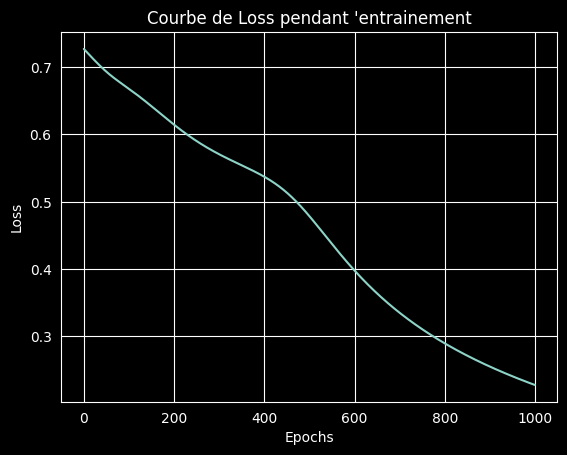

In [6]:
# Exercice 1

# Données avec labels décrivant un XOR entre deux bits
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y= np.array([0,1,1,0])


# Normalisation des données d'entrée
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Creation d'un model sequentiel
mlp_model = Sequential()

# Couche d'entrée avec entrées et une premiere couche cachée de 4 neuronnes
mlp_model.add(Dense(4,input_dim=2,activation='tanh'))

# Couche cachée de 2 neuronnes
mlp_model.add(Dense(2,input_dim=2,activation='tanh'))

#Couche de sortie avec fonction d'activation sigmoide
mlp_model.add(Dense(1, input_dim=2, activation='sigmoid'))

# Compilation du modele
mlp_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
mlp_model.summary()



# Entrainement du model
history = mlp_model.fit(X_normalized, y, epochs=1000, verbose=1)


# Prédictions sur les données d'entrée
predictions = mlp_model.predict(X_normalized)

# Affichage des prédictions continues (probabilité)
print(f"predictions: {predictions}")

# Conversion des valeurs continues en valeurs binaires  (0 ou 1) avec un seuil de 0.5
predictions_binary = (predictions > 0.5).astype(int)

# Affichage des prédictions binaires
print(f"predictions_binary: {predictions_binary}")


# Courbe loss pendant l'entrainement
plt.plot(history.history['loss'])
plt.title('Courbe de Loss pendant \'entrainement')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [11]:
# Exercice 2


# Définition des fichiers et dossiers
image_folder = "images_small"  # Dossier contenant les images redimensionnées
label_file = "labels.txt"  # Fichier contenant les labels

# Lire les labels depuis le fichier
with open(label_file, "r") as f:
    labels = [line.strip() for line in f.readlines()]

# Obtenir la liste triée des images
image_files = sorted([file for file in os.listdir(image_folder) if file.lower().endswith(('.png', '.jpg', '.jpeg'))])

# Vérifier que le nombre d'images correspond au nombre de labels
if len(image_files) != len(labels):
    print("Avertissement: Le nombre d'images et de labels ne correspond pas !")

# Charger les images, les transformer en vecteurs et les normaliser
images = []
for filename in image_files:
    img_path = os.path.join(image_folder, filename)
    img = Image.open(img_path).convert('RGB')  # Convertir en RGB si nécessaire
    img_array = np.array(img).flatten()  # Transformer l'image en vecteur
    img_array = img_array / 255.0  # Normalisation entre 0 et 1
    images.append(img_array)

# Conversion en tableau NumPy
images = np.array(images)
labels = np.array(labels)

print(f"Chargé {len(images)} images et labels depuis {image_folder} et {label_file}.")
print("Dimensions des images vectorisées:", images.shape)

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Sauvegarder les ensembles d'entraînement et de test dans des fichiers
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

print("Fichiers de train et de test générés et sauvegardés.")


# Liste des catégories
labels_list = [labels[0]]
temp = labels[0]
for label in labels:
    if label == temp:
        pass
    else :
        labels_list.append(str(label))
        temp = label


# Taille et analyse de la variable image
print(len(images))
# La variable image contient des tableaux representant chacun les vecteurs des images chargées


# Affichage des images par catégorie

for(label) in labels_list:
    for image_name in image_files:
        if image_name.lower().startswith(label):
            Image.open(os.path.join(image_folder, image_name)).show()
            break






#



Chargé 119 images et labels depuis images_small et labels.txt.
Dimensions des images vectorisées: (119, 3072)
Fichiers de train et de test générés et sauvegardés.
[np.str_('banane'), 'cerise', 'mirabelle', 'orange', 'pomme', 'prune']
